In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# function to clean special cases like '(-)' and convert to negative float
def clean_value(val):
    val = str(val).replace('(-)', '-')
    val = val.replace(',', '')  # Remove commas
    try:
        return float(val)
    except ValueError:
        return 0

In [ ]:
def get_data(file_name, opening_balance_quantity, opening_balance_value):
  data = pd.read_excel(file_name)
  data.columns = ['Particulars', 'Inwards Quantity', 'Inwards Value', 'Outwards Quantity', 'Outwards Value']
  cleaned_data = data.drop([0, 1], errors='ignore')
  cleaned_data.reset_index(drop=True, inplace=True)

  # Convert 'Particulars' to datetime
  cleaned_data['Particulars'] = pd.to_datetime(cleaned_data['Particulars'])
  # Extract month and year
  cleaned_data['Particulars'] = cleaned_data['Particulars'].dt.strftime('%B-%y')

  cleaned_data['Inwards Value'] = cleaned_data['Inwards Value'].apply(clean_value)
  cleaned_data['Outwards Value'] = cleaned_data['Outwards Value'].apply(clean_value)

  cleaned_data['Inwards Quantity'] = cleaned_data['Inwards Quantity'].str.replace(' BOX', '').apply(clean_value)
  cleaned_data['Outwards Quantity'] = cleaned_data['Outwards Quantity'].str.replace(' BOX', '').apply(clean_value)

  # Replace NaN with 0
  cleaned_data.fillna(0, inplace=True)

  cleaned_data['Closing Quantity'] = 0.0
  cleaned_data['Closing Value'] = 0.0

  # Iterate over the rows to compute the cumulative closing values and quantities
  for i in range(len(cleaned_data)):
      if i == 0:
          cleaned_data.at[i, 'Opening Quantity'] = opening_balance_quantity
          cleaned_data.at[i, 'Closing Quantity'] = round(opening_balance_quantity + cleaned_data.iloc[i]['Inwards Quantity'] - cleaned_data.iloc[i]['Outwards Quantity'],2)
          # cleaned_data.at[i, 'Closing Value'] = opening_balance_value + cleaned_data.iloc[i]['Inwards Value'] - cleaned_data.iloc[i]['Outwards Value']
      else:
          cleaned_data.at[i, 'Opening Quantity'] = cleaned_data.iloc[i - 1]['Closing Quantity']
          cleaned_data.at[i, 'Closing Quantity'] = round(cleaned_data.iloc[i-1]['Closing Quantity'] + cleaned_data.iloc[i]['Inwards Quantity'] - cleaned_data.iloc[i]['Outwards Quantity'],2)
          # cleaned_data.at[i, 'Closing Value'] = cleaned_data.iloc[i-1]['Closing Value'] + cleaned_data.iloc[i]['Inwards Value'] - cleaned_data.iloc[i]['Outwards Value']


  total_inwards_quantity = cleaned_data['Inwards Quantity'].sum()
  total_outwards_quantity = cleaned_data['Outwards Quantity'].sum()
  total_inwards_value = cleaned_data['Inwards Value'].sum()
  total_outwards_value = cleaned_data['Outwards Value'].sum()

  print(f"Total Inwards Quantity: {total_inwards_quantity} BOX")
  print(f"Total Outwards Quantity: {total_outwards_quantity} BOX")
  print(f"Total Inwards Value: {total_inwards_value}")
  print(f"Total Outwards Value: {total_outwards_value}")

  closing_quantity = cleaned_data['Closing Quantity'].iloc[-1]
  # closing_value = cleaned_data['Closing Value'].iloc[-1]
  print(f"Final Closing Quantity: {closing_quantity} BOX")
  # print(f"Final Closing Value: {closing_value}")

  # --------------------------------------------------------------------------
  x = total_outwards_quantity
  y = cleaned_data['Closing Quantity'].mean()

  # Calculate Average Stock and Stock Turnover Ratio (STR)
  cleaned_data['Average Stock'] = (cleaned_data['Opening Quantity'] + cleaned_data['Closing Quantity']) / 2
  cleaned_data['Stock Turnover Ratio'] = cleaned_data['Outwards Quantity'] / cleaned_data['Average Stock']

  # Display the result
  # print(cleaned_data)
  return cleaned_data,x,y

In [ ]:
# files =['100x300.xlsx','1200x1800.xlsx','24x12.xlsx','600x1200.xlsx','800x1600.xlsx','800x2400b.xlsx','800x3000.xlsx']

print('100x300')
df_100x300,total_outwards_quantity100x300,average_closing_quantity100x300 = get_data('100x300.xlsx',12.78, 9907.82)
print('1200x1800')
df_1200x1800,total_outwards_quantity1200x1800,average_closing_quantity1200x1800 = get_data('1200x1800.xlsx',31,98542.81)
print('24x12')
df_24x12,total_outwards_quantity24x12,average_closing_quantity24x12 = get_data('24x12.xlsx', 228.46, 93321.04)
print('600x1200')
df_600x1200,total_outwards_quantity600x1200,average_closing_quantity600x1200 = get_data('600x1200.xlsx',390.50, 290963.83)
print('800x1600')
df_800x1600,total_outwards_quantity800x1600,average_closing_quantity800x1600 = get_data('800x1600.xlsx',24, 34963.07)
print('800x2400b')
df_800x2400b,total_outwards_quantity800x2400b,average_closing_quantity800x2400b = get_data('800x2400b.xlsx',5.00, 15338.56)
print('800x3000')
df_800x3000,total_outwards_quantity800x3000,average_closing_quantity800x3000 = get_data('800x3000.xlsx',0.0,0.0)


100x300
Total Inwards Quantity: 247.56 BOX
Total Outwards Quantity: 264.34000000000003 BOX
Total Inwards Value: 132794.88999999998
Total Outwards Value: 171718.9
Final Closing Quantity: -4.0 BOX
1200x1800
Total Inwards Quantity: 130.0 BOX
Total Outwards Quantity: 149.75 BOX
Total Inwards Value: 507633.42
Total Outwards Value: 621110.3899999999
Final Closing Quantity: 11.25 BOX
24x12
Total Inwards Quantity: 3125.15 BOX
Total Outwards Quantity: 3274.01 BOX
Total Inwards Value: 1272469.56
Total Outwards Value: 1575024.3399999999
Final Closing Quantity: 79.6 BOX
600x1200
Total Inwards Quantity: 6187.0 BOX
Total Outwards Quantity: 6440.0 BOX
Total Inwards Value: 4913784.17
Total Outwards Value: 5912896.21
Final Closing Quantity: 137.5 BOX
800x1600
Total Inwards Quantity: 685.0 BOX
Total Outwards Quantity: 708.5 BOX
Total Inwards Value: 1042411.71
Total Outwards Value: 1179762.1099999999
Final Closing Quantity: 0.5 BOX
800x2400b
Total Inwards Quantity: 288.0 BOX
Total Outwards Quantity: 295.

# **Visualize Trends**

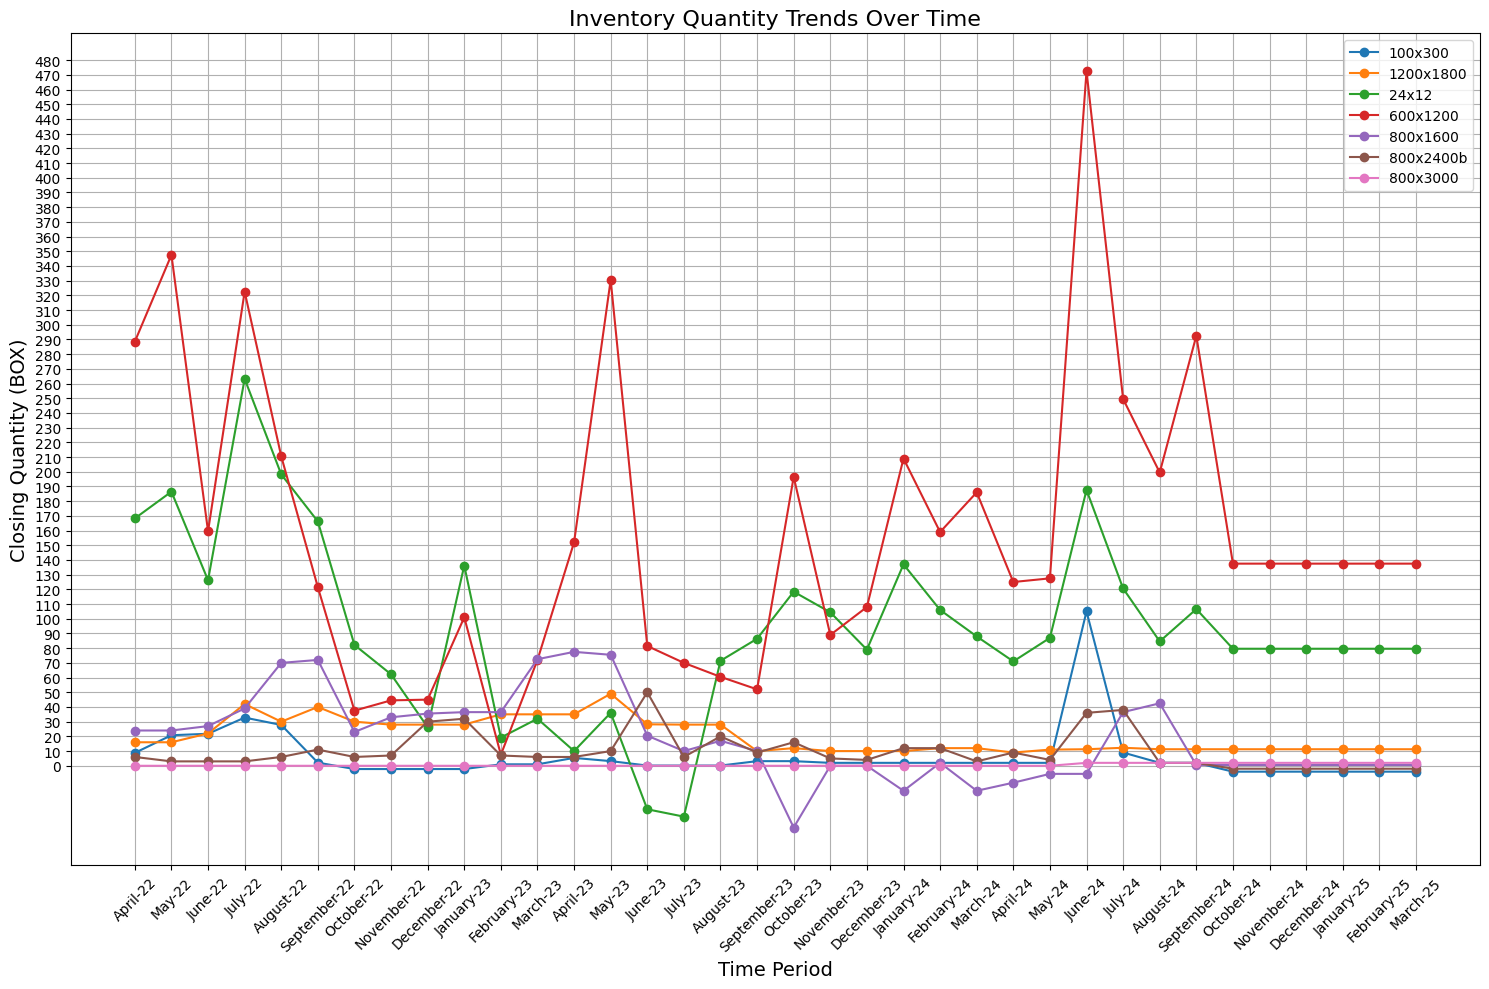

In [ ]:
# Plot trends for Closing quantity over time
plt.figure(figsize=(15, 10))

plt.plot(df_100x300['Particulars'], df_100x300['Closing Quantity'], label='100x300', marker='o')
plt.plot(df_1200x1800['Particulars'], df_1200x1800['Closing Quantity'], label='1200x1800', marker='o')
plt.plot(df_24x12['Particulars'], df_24x12['Closing Quantity'], label='24x12', marker='o')
plt.plot(df_600x1200['Particulars'], df_600x1200['Closing Quantity'], label='600x1200', marker='o')
plt.plot(df_800x1600['Particulars'], df_800x1600['Closing Quantity'], label='800x1600', marker='o')
plt.plot(df_800x2400b['Particulars'], df_800x2400b['Closing Quantity'], label='800x2400b', marker='o')
plt.plot(df_800x3000['Particulars'], df_800x3000['Closing Quantity'], label='800x3000', marker='o')

plt.title('Inventory Quantity Trends Over Time', fontsize=16)
plt.xlabel('Time Period', fontsize=14)
plt.ylabel('Closing Quantity (BOX)', fontsize=14)

# Manually set y-axis tick marks (0, 50, 100, etc.)
plt.yticks(range(0, int(max(df_100x300['Closing Quantity'].max(), df_1200x1800['Closing Quantity'].max(),
                            df_24x12['Closing Quantity'].max(), df_600x1200['Closing Quantity'].max(),
                            df_800x1600['Closing Quantity'].max(), df_800x2400b['Closing Quantity'].max(),
                            df_800x3000['Closing Quantity'].max()) + 10), 10))
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


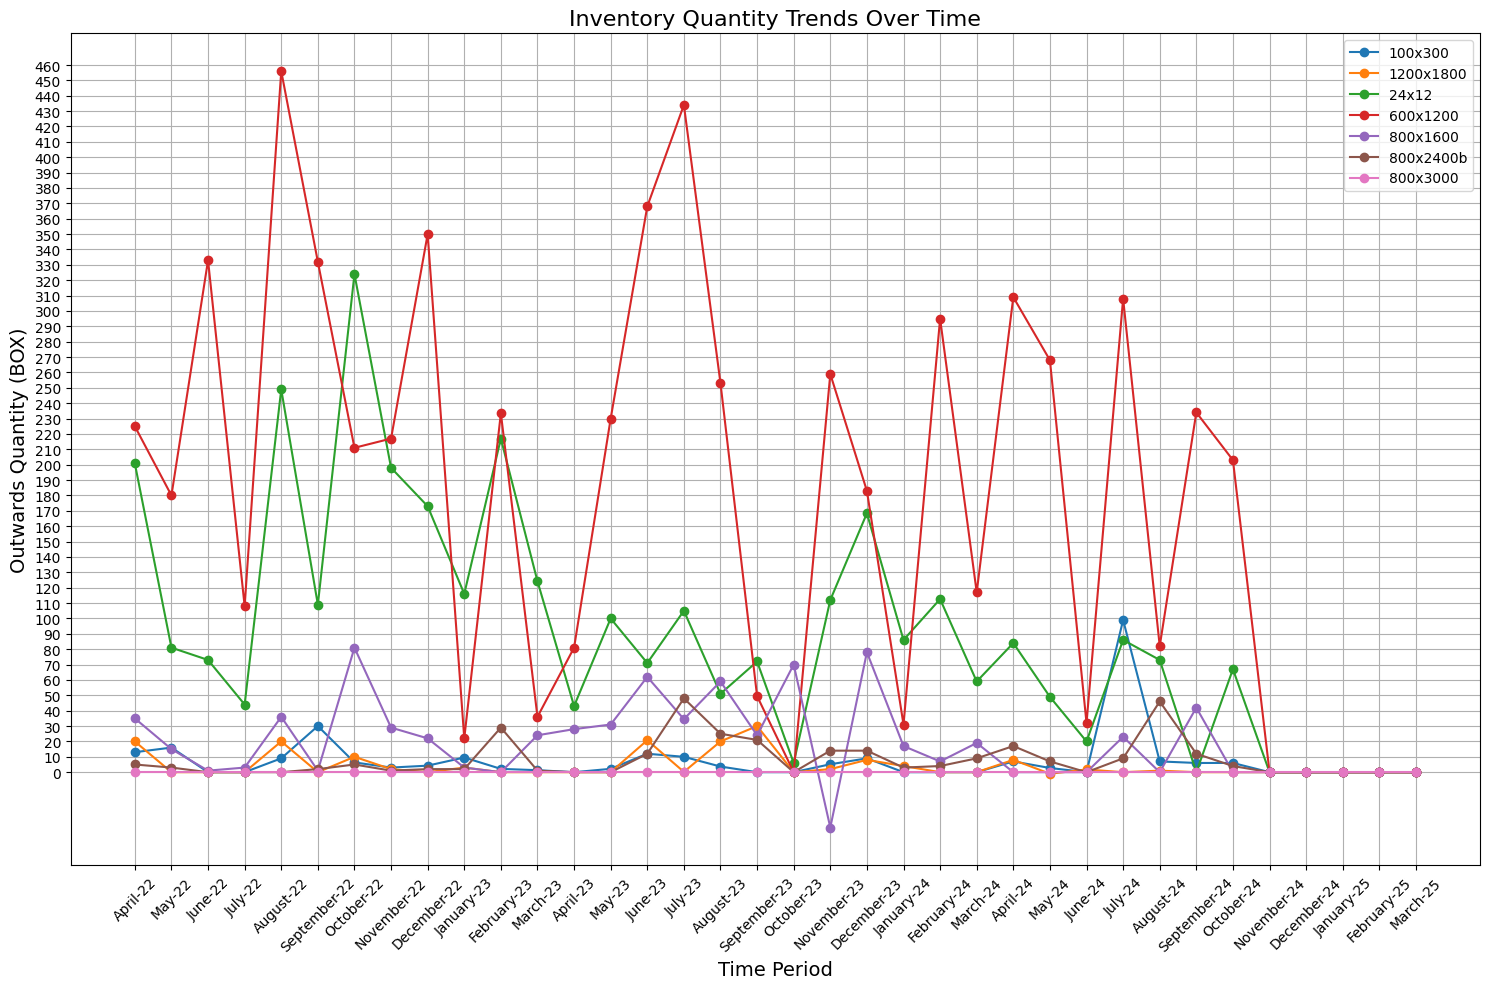

In [ ]:
# Plot trends for Outwards quantity over time
plt.figure(figsize=(15, 10))

plt.plot(df_100x300['Particulars'], df_100x300['Outwards Quantity'], label='100x300', marker='o')
plt.plot(df_1200x1800['Particulars'], df_1200x1800['Outwards Quantity'], label='1200x1800', marker='o')
plt.plot(df_24x12['Particulars'], df_24x12['Outwards Quantity'], label='24x12', marker='o')
plt.plot(df_600x1200['Particulars'], df_600x1200['Outwards Quantity'], label='600x1200', marker='o')
plt.plot(df_800x1600['Particulars'], df_800x1600['Outwards Quantity'], label='800x1600', marker='o')
plt.plot(df_800x2400b['Particulars'], df_800x2400b['Outwards Quantity'], label='800x2400b', marker='o')
plt.plot(df_800x3000['Particulars'], df_800x3000['Outwards Quantity'], label='800x3000', marker='o')

plt.title('Inventory Quantity Trends Over Time', fontsize=16)
plt.xlabel('Time Period', fontsize=14)
plt.ylabel('Outwards Quantity (BOX)', fontsize=14)

plt.yticks(range(0, int(max(df_100x300['Outwards Quantity'].max(), df_1200x1800['Outwards Quantity'].max(),
                            df_24x12['Outwards Quantity'].max(), df_600x1200['Outwards Quantity'].max(),
                            df_800x1600['Outwards Quantity'].max(), df_800x2400b['Outwards Quantity'].max(),
                            df_800x3000['Outwards Quantity'].max()) + 10), 10))
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Additional Analysis**

In [ ]:
# Calculate the product turnover rate
print("100x300")
turnover_rate100x300 = total_outwards_quantity100x300 / average_closing_quantity100x300
print(f"Total Outwards Quantity: {total_outwards_quantity100x300:.2f} BOX")
print(f"Average Inventory (Closing Quantity): {average_closing_quantity100x300:.2f} BOX")
print(f"Product Turnover Rate: {turnover_rate100x300:.2f}")
print()

print("1200x1800")
turnover_rate1200x1800 = total_outwards_quantity1200x1800 / average_closing_quantity1200x1800
print(f"Total Outwards Quantity: {total_outwards_quantity1200x1800:.2f} BOX")
print(f"Average Inventory (Closing Quantity): {average_closing_quantity1200x1800:.2f} BOX")
print(f"Product Turnover Rate: {turnover_rate1200x1800:.2f}")
print()

print("24x12")
turnover_rate24x12 = total_outwards_quantity24x12 / average_closing_quantity24x12
print(f"Total Outwards Quantity: {total_outwards_quantity24x12:.2f} BOX")
print(f"Average Inventory (Closing Quantity): {average_closing_quantity24x12:.2f} BOX")
print(f"Product Turnover Rate: {turnover_rate24x12:.2f}")
print()

print("600x1200")
turnover_rate600x1200 = total_outwards_quantity600x1200 / average_closing_quantity600x1200
print(f"Total Outwards Quantity: {total_outwards_quantity600x1200:.2f} BOX")
print(f"Average Inventory (Closing Quantity): {average_closing_quantity600x1200:.2f} BOX")
print(f"Product Turnover Rate: {turnover_rate600x1200:.2f}")
print()

print("800x1600")
turnover_rate800x1600 = total_outwards_quantity800x1600 / average_closing_quantity800x1600
print(f"Total Outwards Quantity: {total_outwards_quantity800x1600:.2f} BOX")
print(f"Average Inventory (Closing Quantity): {average_closing_quantity800x1600:.2f} BOX")
print(f"Product Turnover Rate: {turnover_rate800x1600:.2f}")
print()

print("800x2400b")
turnover_rate800x2400b = total_outwards_quantity800x2400b / average_closing_quantity800x2400b
print(f"Total Outwards Quantity: {total_outwards_quantity800x2400b:.2f} BOX")
print(f"Average Inventory (Closing Quantity): {average_closing_quantity800x2400b:.2f} BOX")
print(f"Product Turnover Rate: {turnover_rate800x2400b:.2f}")
print()

print("800x3000")
turnover_rate800x3000 = total_outwards_quantity800x3000 / average_closing_quantity800x3000
print(f"Total Outwards Quantity: {total_outwards_quantity800x3000:.2f} BOX")
print(f"Average Inventory (Closing Quantity): {average_closing_quantity800x3000:.2f} BOX")
print(f"Product Turnover Rate: {turnover_rate800x3000:.2f}")

100x300
Total Outwards Quantity: 264.34 BOX
Average Inventory (Closing Quantity): 6.40 BOX
Product Turnover Rate: 41.29

1200x1800
Total Outwards Quantity: 149.75 BOX
Average Inventory (Closing Quantity): 20.21 BOX
Product Turnover Rate: 7.41

24x12
Total Outwards Quantity: 3274.01 BOX
Average Inventory (Closing Quantity): 93.72 BOX
Product Turnover Rate: 34.93

600x1200
Total Outwards Quantity: 6440.00 BOX
Average Inventory (Closing Quantity): 159.53 BOX
Product Turnover Rate: 40.37

800x1600
Total Outwards Quantity: 708.50 BOX
Average Inventory (Closing Quantity): 19.15 BOX
Product Turnover Rate: 36.99

800x2400b
Total Outwards Quantity: 295.00 BOX
Average Inventory (Closing Quantity): 9.78 BOX
Product Turnover Rate: 30.17

800x3000
Total Outwards Quantity: 0.00 BOX
Average Inventory (Closing Quantity): 0.56 BOX
Product Turnover Rate: 0.00


In [ ]:
turnover_rates = {
    "100x300": 41.29,
    "1200x1800": 7.41,
    "24x12": 34.93,
    "600x1200": 40.37,
    "800x1600": 36.99,
    "800x2400b": 30.17,
    "800x3000": 0.00
}

max_turnover_rate = max(turnover_rates.values())
# Scale the turnover rates to a 0-10 range
scaled_turnover_rates = {size: (rate / max_turnover_rate) * 10 for size, rate in turnover_rates.items()}

# Display the scaled turnover rates
print("Scaled Turnover Rates (0-10 scale):")
for size, scaled_rate in scaled_turnover_rates.items():
    print(f"{size}: {scaled_rate:.2f}")

# Categorization
print("\nCategorization:")
for size, scaled_rate in scaled_turnover_rates.items():
    if scaled_rate >= 7.5:
        category = "Fast-Selling"
    elif scaled_rate >= 3:
        category = "Medium-Selling"
    else:
        category = "Slow-Selling"
    print(f"{size}: {scaled_rate:.2f} - {category}")


Scaled Turnover Rates (0-10 scale):
100x300: 10.00
1200x1800: 1.79
24x12: 8.46
600x1200: 9.78
800x1600: 8.96
800x2400b: 7.31
800x3000: 0.00

Categorization:
100x300: 10.00 - Fast-Selling
1200x1800: 1.79 - Slow-Selling
24x12: 8.46 - Fast-Selling
600x1200: 9.78 - Fast-Selling
800x1600: 8.96 - Fast-Selling
800x2400b: 7.31 - Medium-Selling
800x3000: 0.00 - Slow-Selling


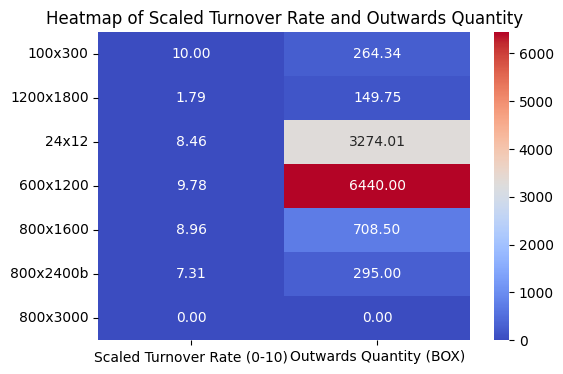

In [ ]:
data_matrix = np.array([[scaled_turnover_rates['100x300'], total_outwards_quantity100x300],
                        [scaled_turnover_rates['1200x1800'], total_outwards_quantity1200x1800],
                        [scaled_turnover_rates['24x12'], total_outwards_quantity24x12],
                        [scaled_turnover_rates['600x1200'], total_outwards_quantity600x1200],
                        [scaled_turnover_rates['800x1600'], total_outwards_quantity800x1600],
                        [scaled_turnover_rates['800x2400b'], total_outwards_quantity800x2400b],
                        [scaled_turnover_rates['800x3000'], total_outwards_quantity800x3000]])

# Define labels for products and metrics
products = ['100x300', '1200x1800', '24x12', '600x1200', '800x1600', '800x2400b', '800x3000']
metrics = ['Scaled Turnover Rate (0-10)', 'Outwards Quantity (BOX)']

# Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(data_matrix, annot=True, fmt=".2f", cmap='coolwarm', xticklabels=metrics, yticklabels=products)
plt.title('Heatmap of Scaled Turnover Rate and Outwards Quantity')
plt.show()

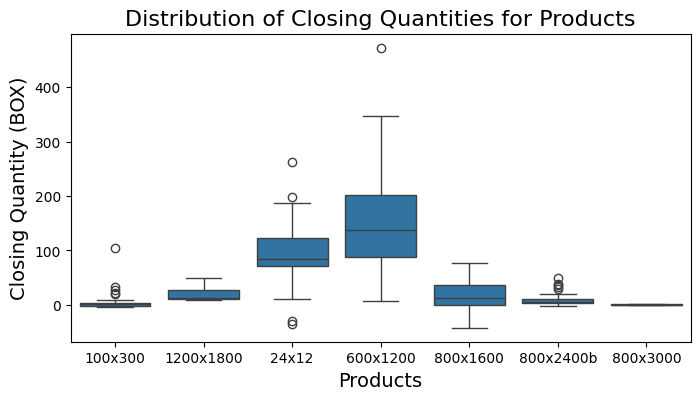

In [ ]:
min_length = min(len(df_100x300["Closing Quantity"]), len(df_1200x1800["Closing Quantity"]),
                 len(df_24x12["Closing Quantity"]), len(df_600x1200["Closing Quantity"]),
                 len(df_800x1600["Closing Quantity"]), len(df_800x2400b["Closing Quantity"]),
                 len(df_800x3000["Closing Quantity"]))
closing_quantities = {
    '100x300': df_100x300["Closing Quantity"].iloc[:min_length],
    '1200x1800': df_1200x1800["Closing Quantity"].iloc[:min_length],
    '24x12': df_24x12["Closing Quantity"].iloc[:min_length],
    '600x1200': df_600x1200["Closing Quantity"].iloc[:min_length],
    '800x1600': df_800x1600["Closing Quantity"].iloc[:min_length],
    '800x2400b': df_800x2400b["Closing Quantity"].iloc[:min_length],
    '800x3000': df_800x3000["Closing Quantity"].iloc[:min_length]
}
data = {
    'Product': sum([[product] * len(closing_quantities[product]) for product in products], []),
    'Closing Quantity': sum([closing_quantities[product].tolist() for product in products], [])
}

df = pd.DataFrame(data)

plt.figure(figsize=(8, 4))
sns.boxplot(x='Product', y='Closing Quantity', data=df)

plt.title('Distribution of Closing Quantities for Products', fontsize=16)
plt.xlabel('Products', fontsize=14)
plt.ylabel('Closing Quantity (BOX)', fontsize=14)
plt.show()


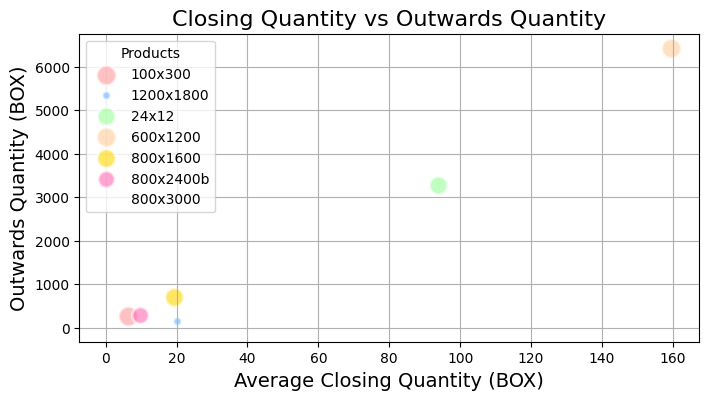

In [ ]:
closing_quantities = [
    average_closing_quantity100x300,
    average_closing_quantity1200x1800,
    average_closing_quantity24x12,
    average_closing_quantity600x1200,
    average_closing_quantity800x1600,
    average_closing_quantity800x2400b,
    average_closing_quantity800x3000
]
outwards_quantities = [
    total_outwards_quantity100x300,
    total_outwards_quantity1200x1800,
    total_outwards_quantity24x12,
    total_outwards_quantity600x1200,
    total_outwards_quantity800x1600,
    total_outwards_quantity800x2400b,
    total_outwards_quantity800x3000
]
turnover_rates = [
    scaled_turnover_rates['100x300'],
    scaled_turnover_rates['1200x1800'],
    scaled_turnover_rates['24x12'],
    scaled_turnover_rates['600x1200'],
    scaled_turnover_rates['800x1600'],
    scaled_turnover_rates['800x2400b'],
    scaled_turnover_rates['800x3000']
]
colors = ['#FF9999', '#66B3FF', '#99FF99', '#FFCC99', '#FFD700', '#FF69B4', '#BA55D3']
plt.figure(figsize=(8, 4))

# Plot each product with a different color
for i in range(len(closing_quantities)):
    plt.scatter(closing_quantities[i], outwards_quantities[i],
                s=turnover_rates[i] * 20,  # Scale size
                color=colors[i], alpha=0.6, edgecolors="w", linewidth=2, label=products[i])

plt.title('Closing Quantity vs Outwards Quantity', fontsize=16)
plt.xlabel('Average Closing Quantity (BOX)', fontsize=14)
plt.ylabel('Outwards Quantity (BOX)', fontsize=14)

products = ['100x300', '1200x1800', '24x12', '600x1200',
            '800x1600', '800x2400b', '800x3000']
plt.legend(title='Products', loc='upper left')
plt.grid(True)
plt.show()
